# LSTM Volleyball Rally Outcome Prediction

Sequence model for predicting rally winners from VREN-encoded volleyball data.

**Key improvement over MLP baseline:** treats each rally as a *sequence* of rounds
(serve → reception → set → attack → defense → …) rather than independent rows.

**Architecture:** per-feature learned embeddings → LSTM → classifier head.

**Dataset:** 1,500 rallies (2,429 total rounds) from NCAA D-I men's volleyball.

In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Data Loading & Rally Segmentation

The `rally` column resets across games, so we detect game boundaries
(where `rally` decreases) and create a truly unique rally identifier.

In [2]:
df = pd.read_csv("dataset_full.csv")
print(f"Raw shape: {df.shape}")

# Detect game boundaries where rally number resets (decreases)
game_ids = [0]
for i in range(1, len(df)):
    if df.iloc[i]["rally"] < df.iloc[i - 1]["rally"]:
        game_ids.append(game_ids[-1] + 1)
    else:
        game_ids.append(game_ids[-1])

df["game_id"] = game_ids
df["unique_rally"] = df["game_id"].astype(str) + "_" + df["rally"].astype(str)

# Drop target-leaking columns
LEAKY_COLS = ["win_reason", "lose_reason"]
df = df.drop(columns=LEAKY_COLS)

# Verify winning_team is consistent within each rally
assert df.groupby("unique_rally")["winning_team"].nunique().max() == 1, \
    "winning_team is not consistent within rallies!"

# Dataset statistics
rally_lengths = df.groupby("unique_rally").size()
rally_winners = df.groupby("unique_rally")["winning_team"].first()

print(f"Games: {df['game_id'].nunique()}")
print(f"Unique rallies: {df['unique_rally'].nunique()}")
print(f"Rally lengths: min={rally_lengths.min()}, max={rally_lengths.max()}, "
      f"mean={rally_lengths.mean():.1f}, median={rally_lengths.median():.0f}")
print(f"Single-round rallies: {(rally_lengths == 1).sum()} / {len(rally_lengths)} "
      f"({(rally_lengths == 1).mean() * 100:.1f}%)")
print(f"\nWinner distribution:\n{rally_winners.value_counts()}")
df.head()

Raw shape: (2429, 18)
Games: 9
Unique rallies: 1500
Rally lengths: min=1, max=9, mean=1.6, median=1
Single-round rallies: 1008 / 1500 (67.2%)

Winner distribution:
winning_team
a    809
b    691
Name: count, dtype: int64


,rally,round,team,receive_location,digger_location,pass_land_location,hitter_location,hit_land_location,pass_rating,set_type,set_location,hit_type,num_blockers,block_touch,serve_type,winning_team,game_id,unique_rally
0,1,1.0,b,4.0,4.0,13.0,13.0,7.0,in,in,quick,off_speed,2.0,no,jump,a,0,0_1
1,1,2.0,a,7.0,6.0,3.0,11.0,17.0,out,out,oppo,hit,3.0,no,NaN,a,0,0_1
2,1,3.0,b,6.0,6.0,21.0,25.0,13.0,out,out,outside,free_ball,0.0,no,NaN,a,0,0_1
3,1,4.0,a,13.0,13.0,13.0,15.0,4.0,in,in,outside,hit,1.0,no,NaN,a,0,0_1
4,1,5.0,b,9.0,9.0,3.0,15.0,4.0,out,out,outside,hit,3.0,yes,NaN,a,0,0_1


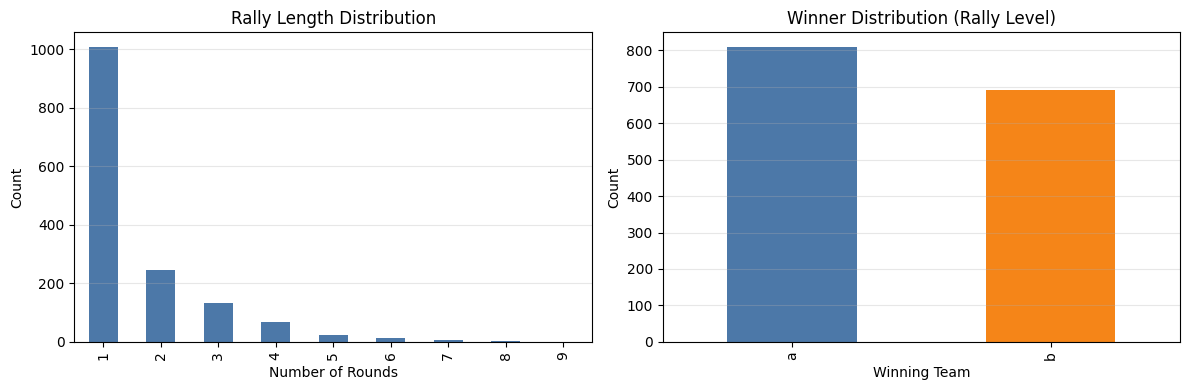

In [3]:
# Rally length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rally_lengths.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Rally Length Distribution")
axes[0].set_xlabel("Number of Rounds")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

rally_winners.value_counts().plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Winner Distribution (Rally Level)")
axes[1].set_xlabel("Winning Team")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Feature Encoding

Each categorical feature gets a learned embedding (index 0 = missing/NaN).
The `round` feature is kept as a normalized float.

In [4]:
# Define categorical feature vocabularies.
# Index 0 is always reserved for missing/NaN values.

# Location features share the same vocab: zones 1-26 → indices 1-26, NaN → 0
LOCATION_COLS = [
    "receive_location", "digger_location", "pass_land_location",
    "hitter_location", "hit_land_location",
]

CAT_FEATURES = {}

# Location columns: vocab_size = 27 (0=missing, 1-26=zones)
for col in LOCATION_COLS:
    CAT_FEATURES[col] = {"vocab_size": 27}

# Other categorical columns: build vocab from data
other_cat_cols = {
    "team":          sorted(df["team"].dropna().unique()),
    "pass_rating":   sorted(df["pass_rating"].dropna().unique()),
    "set_type":      sorted(df["set_type"].dropna().unique()),
    "set_location":  sorted(df["set_location"].dropna().unique()),
    "hit_type":      sorted(df["hit_type"].dropna().unique()),
    "num_blockers":  sorted(df["num_blockers"].dropna().unique()),
    "block_touch":   sorted(df["block_touch"].dropna().unique()),
    "serve_type":    sorted(df["serve_type"].dropna().unique()),
}

for col, values in other_cat_cols.items():
    val_to_idx = {v: i + 1 for i, v in enumerate(values)}  # 0 = missing
    CAT_FEATURES[col] = {"vocab_size": len(values) + 1, "val_to_idx": val_to_idx}

# Compute embedding dimensions: min(vocab_size // 2, 5), floored at 2
for col, info in CAT_FEATURES.items():
    info["embed_dim"] = max(min(info["vocab_size"] // 2, 5), 2)

# Print feature summary
print(f"{'Feature':<22} {'Vocab':>5} {'Embed':>5}")
print("-" * 34)
total_embed_dim = 0
for col, info in CAT_FEATURES.items():
    print(f"{col:<22} {info['vocab_size']:>5} {info['embed_dim']:>5}")
    total_embed_dim += info["embed_dim"]
print(f"\nTotal embedding dim: {total_embed_dim}")
print(f"+ 1 continuous (round) = {total_embed_dim + 1} input features per timestep")

Feature                Vocab Embed
----------------------------------
receive_location          27     5
digger_location           27     5
pass_land_location        27     5
hitter_location           27     5
hit_land_location         27     5
team                       3     2
pass_rating                3     2
set_type                   4     2
set_location               9     4
hit_type                  10     5
num_blockers               5     2
block_touch                3     2
serve_type                 5     2

Total embedding dim: 46
+ 1 continuous (round) = 47 input features per timestep


In [5]:
# Encode each row into categorical indices + continuous round value

CAT_COL_ORDER = list(CAT_FEATURES.keys())  # fixed ordering
MAX_ROUND = df["round"].max()

def encode_row(row):
    """Convert a single DataFrame row into (cat_indices, cont_value)."""
    cat_indices = []
    for col in CAT_COL_ORDER:
        val = row[col]
        info = CAT_FEATURES[col]
        if pd.isna(val):
            cat_indices.append(0)
        elif col in LOCATION_COLS:
            cat_indices.append(int(val))
        else:
            cat_indices.append(info["val_to_idx"].get(val, 0))
    cont = row["round"] / MAX_ROUND if not pd.isna(row["round"]) else 0.0
    return cat_indices, cont


# Build rally-level sequences
rally_data = []  # list of (cat_tensor, cont_tensor, label, length, unique_rally_id)

for rally_id, group in df.groupby("unique_rally", sort=False):
    group = group.sort_values("round")
    label = 1 if group["winning_team"].iloc[0] == "b" else 0

    cat_rows = []
    cont_rows = []
    for _, row in group.iterrows():
        cat_idx, cont_val = encode_row(row)
        cat_rows.append(cat_idx)
        cont_rows.append([cont_val])

    cat_tensor = torch.tensor(cat_rows, dtype=torch.long)   # (seq_len, num_cat)
    cont_tensor = torch.tensor(cont_rows, dtype=torch.float32)  # (seq_len, 1)
    rally_data.append((cat_tensor, cont_tensor, label, len(group), rally_id))

print(f"Encoded {len(rally_data)} rallies")
print(f"Example rally shape: cat={rally_data[0][0].shape}, cont={rally_data[0][1].shape}, "
      f"label={rally_data[0][2]}, length={rally_data[0][3]}")

Encoded 1500 rallies
Example rally shape: cat=torch.Size([8, 13]), cont=torch.Size([8, 1]), label=0, length=8


## 3. Dataset, DataLoader & Train/Val/Test Splits

Split at the **rally level** (not row level) to avoid data leakage.
Custom collate function pads variable-length sequences within each batch.

In [6]:
# Rally-level stratified split: 70 / 15 / 15

labels = np.array([d[2] for d in rally_data])
indices = np.arange(len(rally_data))

train_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=labels
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.1765, random_state=SEED, stratify=labels[train_idx]
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)} rallies")
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    labs = labels[idx]
    print(f"  {name}: team_a={sum(labs == 0)}, team_b={sum(labs == 1)}")

Train: 1049 | Val: 226 | Test: 225 rallies
  Train: team_a=566, team_b=483
  Val: team_a=122, team_b=104
  Test: team_a=121, team_b=104


In [7]:
class RallyDataset(Dataset):
    def __init__(self, data, indices):
        self.samples = [data[i] for i in indices]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cat, cont, label, length, rally_id = self.samples[idx]
        return cat, cont, label, length, rally_id


def collate_fn(batch):
    cats, conts, labels, lengths, rally_ids = zip(*batch)

    # Pad sequences to max length in this batch
    cat_padded = pad_sequence(cats, batch_first=True, padding_value=0)
    cont_padded = pad_sequence(conts, batch_first=True, padding_value=0.0)

    labels = torch.tensor(labels, dtype=torch.float32)
    lengths = torch.tensor(lengths, dtype=torch.long)

    return cat_padded, cont_padded, labels, lengths, rally_ids


BATCH_SIZE = 64

train_ds = RallyDataset(rally_data, train_idx)
val_ds = RallyDataset(rally_data, val_idx)
test_ds = RallyDataset(rally_data, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Sanity check
cat_batch, cont_batch, lab_batch, len_batch, _ = next(iter(train_loader))
print(f"Batch shapes: cat={cat_batch.shape}, cont={cont_batch.shape}, "
      f"labels={lab_batch.shape}, lengths={len_batch.shape}")

Batch shapes: cat=torch.Size([64, 6, 13]), cont=torch.Size([64, 6, 1]), labels=torch.Size([64]), lengths=torch.Size([64])


## 4. LSTM Model Architecture

Per-feature embeddings are concatenated with the normalized round number,
then fed into a 2-layer LSTM. The last hidden state is passed through a
classifier head to produce a binary prediction.

In [8]:
class RallyLSTM(nn.Module):
    def __init__(self, cat_features, cat_col_order, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.cat_col_order = cat_col_order

        # One embedding table per categorical feature
        self.embeddings = nn.ModuleDict()
        total_embed_dim = 0
        for col in cat_col_order:
            info = cat_features[col]
            self.embeddings[col] = nn.Embedding(
                num_embeddings=info["vocab_size"],
                embedding_dim=info["embed_dim"],
                padding_idx=0,
            )
            total_embed_dim += info["embed_dim"]

        self.input_dim = total_embed_dim + 1  # +1 for round

        self.lstm = nn.LSTM(
            input_size=self.input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_cat, x_cont, lengths):
        # x_cat: (batch, seq_len, num_cat_features)
        # x_cont: (batch, seq_len, 1)
        # lengths: (batch,)

        # Embed each categorical feature and concatenate
        embedded = []
        for i, col in enumerate(self.cat_col_order):
            embedded.append(self.embeddings[col](x_cat[:, :, i]))
        embedded.append(x_cont)
        x = torch.cat(embedded, dim=-1)  # (batch, seq_len, input_dim)

        # Pack for variable-length sequences
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)

        # Use the last layer's hidden state
        h = h_n[-1]  # (batch, hidden_size)
        logits = self.classifier(h)
        return logits.squeeze(-1)


model = RallyLSTM(CAT_FEATURES, CAT_COL_ORDER, hidden_size=64, num_layers=2, dropout=0.3).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()
print(model)

Total parameters: 65,128
Trainable parameters: 65,128

RallyLSTM(
  (embeddings): ModuleDict(
    (receive_location): Embedding(27, 5, padding_idx=0)
    (digger_location): Embedding(27, 5, padding_idx=0)
    (pass_land_location): Embedding(27, 5, padding_idx=0)
    (hitter_location): Embedding(27, 5, padding_idx=0)
    (hit_land_location): Embedding(27, 5, padding_idx=0)
    (team): Embedding(3, 2, padding_idx=0)
    (pass_rating): Embedding(3, 2, padding_idx=0)
    (set_type): Embedding(4, 2, padding_idx=0)
    (set_location): Embedding(9, 4, padding_idx=0)
    (hit_type): Embedding(10, 5, padding_idx=0)
    (num_blockers): Embedding(5, 2, padding_idx=0)
    (block_touch): Embedding(3, 2, padding_idx=0)
    (serve_type): Embedding(5, 2, padding_idx=0)
  )
  (lstm): LSTM(47, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

## 5. Training Loop

Training with early stopping on validation AUC and learning rate scheduling.

In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0.0

    with torch.no_grad():
        for cat, cont, labels, lengths, _ in loader:
            cat, cont, labels = cat.to(device), cont.to(device), labels.to(device)
            logits = model(cat, cont, lengths)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * len(labels)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    preds = (probs >= 0.5).astype(int)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(targets, preds),
        "auc": roc_auc_score(targets, probs),
        "confusion_matrix": confusion_matrix(targets, preds),
        "probs": probs,
        "targets": targets,
    }

In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5
)

EPOCHS = 50
PATIENCE = 10
best_val_auc = -1.0
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    train_probs, train_targets = [], []

    for cat, cont, labels, lengths, _ in train_loader:
        cat, cont, labels = cat.to(device), cont.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(cat, cont, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(labels)
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_targets.append(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_probs = np.concatenate(train_probs)
    train_targets = np.concatenate(train_targets)
    train_acc = accuracy_score(train_targets, (train_probs >= 0.5).astype(int))

    val_metrics = evaluate(model, val_loader, criterion)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_auc": val_metrics["auc"],
    })

    scheduler.step(val_metrics["auc"])

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0 or patience_counter >= PATIENCE:
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc']:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model (val AUC = {best_val_auc:.4f})")

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 01 | train_loss=0.6988 | train_acc=0.4604 | val_loss=0.6968 | val_acc=0.4602 | val_auc=0.5004
Epoch 05 | train_loss=0.6816 | train_acc=0.5748 | val_loss=0.6852 | val_acc=0.5796 | val_auc=0.5833
Epoch 10 | train_loss=0.5352 | train_acc=0.7588 | val_loss=0.6514 | val_acc=0.6858 | val_auc=0.7109
Epoch 15 | train_loss=0.4244 | train_acc=0.8103 | val_loss=0.6911 | val_acc=0.6770 | val_auc=0.7312
Epoch 20 | train_loss=0.3716 | train_acc=0.8446 | val_loss=0.7218 | val_acc=0.6947 | val_auc=0.7413
Epoch 25 | train_loss=0.3113 | train_acc=0.8627 | val_loss=0.8236 | val_acc=0.7212 | val_auc=0.7699
Epoch 30 | train_loss=0.2816 | train_acc=0.8704 | val_loss=0.9185 | val_acc=0.7345 | val_auc=0.7720
Epoch 35 | train_loss=0.2568 | train_acc=0.8961 | val_loss=0.9382 | val_acc=0.7478 | val_auc=0.7831
Epoch 40 | train_loss=0.2300 | train_acc=0.8990 | val_loss=1.0065 | val_acc=0.7655 | val_auc=0.7840
Epoch 45 | train_loss=0.2127 | train_acc=0.9199 | val_loss=0.9974 | val_acc=0.7655 | val_auc=0.7950


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_auc
45,46,0.221703,0.912297,0.985059,0.778761,0.796461
46,47,0.200636,0.918970,0.995261,0.778761,0.800638
47,48,0.207671,0.916111,0.994257,0.778761,0.794648
48,49,0.193393,0.926597,0.991871,0.778761,0.797171
49,50,0.192136,0.924690,1.009315,0.778761,0.797643


## 6. Training Curves

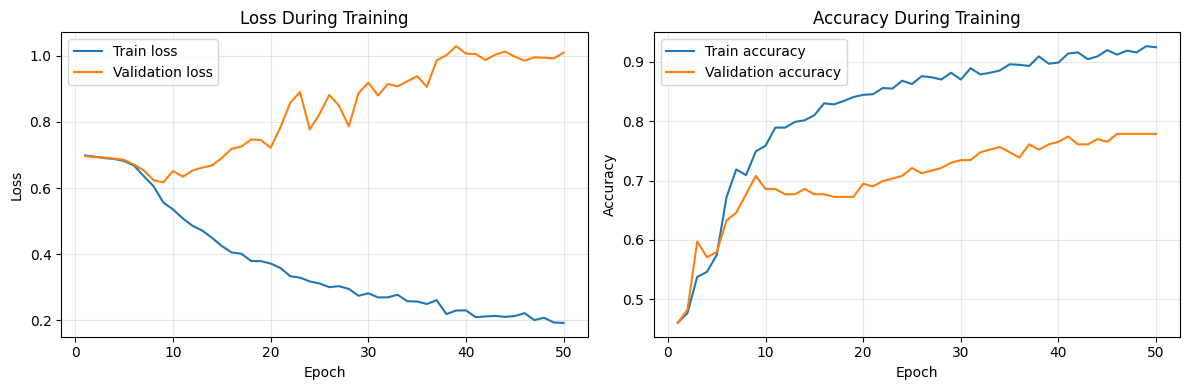

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
axes[0].set_title("Loss During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Accuracy During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Improved Model (v2)

The v1 model shows clear overfitting: train accuracy reaches 92% while val accuracy
plateaus at 78%, and val loss diverges upward after epoch ~10.

**Changes in v2:**
1. **Data augmentation** — team-swap: for each rally, create a mirror copy swapping
   team A ↔ B and flipping the label. Doubles effective training set.
2. **Higher dropout** (0.3 → 0.5) for stronger regularization
3. **Weight decay** (1e-4) in Adam optimizer for L2 regularization
4. **Smaller hidden size** (64 → 32) to reduce model capacity
5. **Gradient clipping** (max_norm=1.0) for training stability

In [16]:
# Data augmentation: team-swap
# For each rally, create a mirror where team a <-> b and label is flipped.
# The "team" feature column index in CAT_COL_ORDER:
team_col_idx = CAT_COL_ORDER.index("team")
team_a_idx = CAT_FEATURES["team"]["val_to_idx"]["a"]
team_b_idx = CAT_FEATURES["team"]["val_to_idx"]["b"]

def swap_team(cat_tensor, label):
    """Create an augmented copy with team labels swapped and target flipped."""
    cat_aug = cat_tensor.clone()
    team_col = cat_aug[:, team_col_idx]
    # Swap: where it was team_a, make team_b, and vice versa
    new_col = torch.where(team_col == team_a_idx, team_b_idx,
              torch.where(team_col == team_b_idx, team_a_idx, team_col))
    cat_aug[:, team_col_idx] = new_col
    new_label = 1 - label
    return cat_aug, new_label


class AugmentedRallyDataset(Dataset):
    """Rally dataset with team-swap augmentation (doubles effective size)."""
    def __init__(self, data, indices, augment=True):
        self.samples = [data[i] for i in indices]
        self.augment = augment

    def __len__(self):
        return len(self.samples) * (2 if self.augment else 1)

    def __getitem__(self, idx):
        is_augmented = idx >= len(self.samples)
        real_idx = idx % len(self.samples)
        cat, cont, label, length, rally_id = self.samples[real_idx]

        if is_augmented:
            cat, label = swap_team(cat, label)
            rally_id = rally_id + "_aug"

        return cat, cont, label, length, rally_id


# Build augmented train loader, keep val/test unchanged
train_ds_v2 = AugmentedRallyDataset(rally_data, train_idx, augment=True)
train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print(f"Original train size: {len(train_ds)}")
print(f"Augmented train size: {len(train_ds_v2)}")
print(f"Val size: {len(val_ds)} | Test size: {len(test_ds)}")

Original train size: 1049
Augmented train size: 2098
Val size: 226 | Test size: 225


In [17]:
# v2 model: smaller hidden size, higher dropout
model_v2 = RallyLSTM(
    CAT_FEATURES, CAT_COL_ORDER,
    hidden_size=32,
    num_layers=2,
    dropout=0.5,
).to(device)

total_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"v1 parameters: {total_params:,}")
print(f"v2 parameters: {total_params_v2:,}")
print()
print(model_v2)

v1 parameters: 65,128
v2 parameters: 20,712

RallyLSTM(
  (embeddings): ModuleDict(
    (receive_location): Embedding(27, 5, padding_idx=0)
    (digger_location): Embedding(27, 5, padding_idx=0)
    (pass_land_location): Embedding(27, 5, padding_idx=0)
    (hitter_location): Embedding(27, 5, padding_idx=0)
    (hit_land_location): Embedding(27, 5, padding_idx=0)
    (team): Embedding(3, 2, padding_idx=0)
    (pass_rating): Embedding(3, 2, padding_idx=0)
    (set_type): Embedding(4, 2, padding_idx=0)
    (set_location): Embedding(9, 4, padding_idx=0)
    (hit_type): Embedding(10, 5, padding_idx=0)
    (num_blockers): Embedding(5, 2, padding_idx=0)
    (block_touch): Embedding(3, 2, padding_idx=0)
    (serve_type): Embedding(5, 2, padding_idx=0)
  )
  (lstm): LSTM(47, 32, num_layers=2, batch_first=True, dropout=0.5)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace

In [18]:
# v2 training loop with weight decay and gradient clipping

criterion_v2 = nn.BCEWithLogitsLoss()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode="max", patience=5, factor=0.5
)

EPOCHS_V2 = 60
PATIENCE_V2 = 12
best_val_auc_v2 = -1.0
best_state_v2 = None
patience_counter_v2 = 0
history_v2 = []

for epoch in range(1, EPOCHS_V2 + 1):
    model_v2.train()
    running_loss = 0.0
    train_probs, train_targets = [], []

    for cat, cont, labels_batch, lengths, _ in train_loader_v2:
        cat, cont, labels_batch = cat.to(device), cont.to(device), labels_batch.to(device)

        optimizer_v2.zero_grad()
        logits = model_v2(cat, cont, lengths)
        loss = criterion_v2(logits, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
        optimizer_v2.step()

        running_loss += loss.item() * len(labels_batch)
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_targets.append(labels_batch.cpu().numpy())

    train_loss = running_loss / len(train_loader_v2.dataset)
    train_probs = np.concatenate(train_probs)
    train_targets = np.concatenate(train_targets)
    train_acc = accuracy_score(train_targets, (train_probs >= 0.5).astype(int))

    val_metrics = evaluate(model_v2, val_loader, criterion_v2)

    history_v2.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_auc": val_metrics["auc"],
    })

    scheduler_v2.step(val_metrics["auc"])

    if val_metrics["auc"] > best_val_auc_v2:
        best_val_auc_v2 = val_metrics["auc"]
        best_state_v2 = copy.deepcopy(model_v2.state_dict())
        patience_counter_v2 = 0
    else:
        patience_counter_v2 += 1

    if epoch == 1 or epoch % 5 == 0 or patience_counter_v2 >= PATIENCE_V2:
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc']:.4f}"
        )

    if patience_counter_v2 >= PATIENCE_V2:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_v2 is not None:
    model_v2.load_state_dict(best_state_v2)
    print(f"\nLoaded best v2 model (val AUC = {best_val_auc_v2:.4f})")

history_v2_df = pd.DataFrame(history_v2)
history_v2_df.tail()

Epoch 01 | train_loss=0.6939 | train_acc=0.4990 | val_loss=0.6912 | val_acc=0.5398 | val_auc=0.5695
Epoch 05 | train_loss=0.6878 | train_acc=0.5834 | val_loss=0.6816 | val_acc=0.6593 | val_auc=0.6789
Epoch 10 | train_loss=0.5851 | train_acc=0.7216 | val_loss=0.5932 | val_acc=0.7035 | val_auc=0.7582
Epoch 15 | train_loss=0.5203 | train_acc=0.7636 | val_loss=0.5283 | val_acc=0.7389 | val_auc=0.8169
Epoch 20 | train_loss=0.4378 | train_acc=0.8117 | val_loss=0.4336 | val_acc=0.8142 | val_auc=0.8799
Epoch 25 | train_loss=0.3698 | train_acc=0.8418 | val_loss=0.3628 | val_acc=0.8496 | val_auc=0.9185
Epoch 30 | train_loss=0.3173 | train_acc=0.8751 | val_loss=0.3379 | val_acc=0.8850 | val_auc=0.9340
Epoch 35 | train_loss=0.2824 | train_acc=0.8932 | val_loss=0.3082 | val_acc=0.9204 | val_auc=0.9419
Epoch 40 | train_loss=0.2474 | train_acc=0.9142 | val_loss=0.3154 | val_acc=0.9248 | val_auc=0.9412
Epoch 45 | train_loss=0.2324 | train_acc=0.9242 | val_loss=0.3158 | val_acc=0.9248 | val_auc=0.9459


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_auc
54,55,0.201669,0.930887,0.352362,0.915929,0.944239
55,56,0.208744,0.935176,0.355130,0.920354,0.941795
56,57,0.201329,0.929457,0.359585,0.915929,0.941401
57,58,0.187388,0.938513,0.351960,0.924779,0.942347
58,59,0.193390,0.934700,0.356524,0.915929,0.942032


## 8. v2 Training Curves & Overfitting Comparison

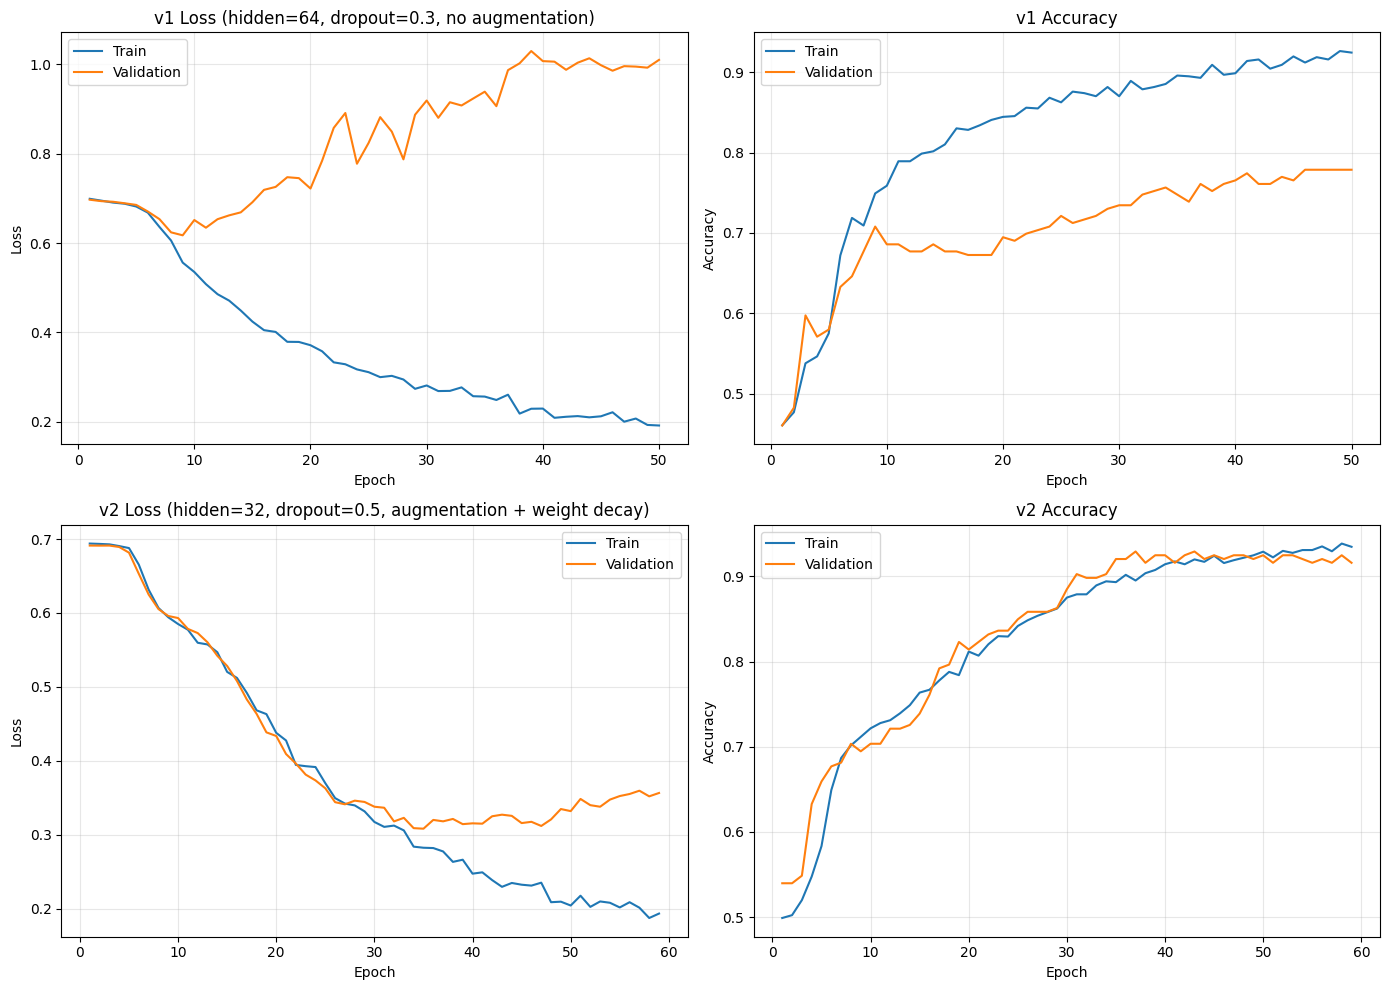

Train-Val accuracy gap at final epoch:
  v1: 0.1459 (train=0.9247, val=0.7788)
  v2: 0.0188 (train=0.9347, val=0.9159)

Best val AUC: v1=0.8006, v2=0.9469


In [19]:
# Compare v1 and v2 training curves side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# v1 curves (top row)
axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0, 0].set_title("v1 Loss (hidden=64, dropout=0.3, no augmentation)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
axes[0, 1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation")
axes[0, 1].set_title("v1 Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# v2 curves (bottom row)
axes[1, 0].plot(history_v2_df["epoch"], history_v2_df["train_loss"], label="Train")
axes[1, 0].plot(history_v2_df["epoch"], history_v2_df["val_loss"], label="Validation")
axes[1, 0].set_title("v2 Loss (hidden=32, dropout=0.5, augmentation + weight decay)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_v2_df["epoch"], history_v2_df["train_accuracy"], label="Train")
axes[1, 1].plot(history_v2_df["epoch"], history_v2_df["val_accuracy"], label="Validation")
axes[1, 1].set_title("v2 Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print overfitting gap comparison
v1_gap = history_df.iloc[-1]["train_accuracy"] - history_df.iloc[-1]["val_accuracy"]
v2_gap = history_v2_df.iloc[-1]["train_accuracy"] - history_v2_df.iloc[-1]["val_accuracy"]
print(f"Train-Val accuracy gap at final epoch:")
print(f"  v1: {v1_gap:.4f} (train={history_df.iloc[-1]['train_accuracy']:.4f}, val={history_df.iloc[-1]['val_accuracy']:.4f})")
print(f"  v2: {v2_gap:.4f} (train={history_v2_df.iloc[-1]['train_accuracy']:.4f}, val={history_v2_df.iloc[-1]['val_accuracy']:.4f})")
print(f"\nBest val AUC: v1={best_val_auc:.4f}, v2={best_val_auc_v2:.4f}")

## 9. Test Evaluation & Model Comparison

In [24]:
# Evaluate both models on test set
test_v1 = evaluate(model, test_loader, criterion)
test_v2 = evaluate(model_v2, test_loader, criterion_v2)

print("Test Metrics — v1 (original)")
print(f"  Loss     : {test_v1['loss']:.4f}")
print(f"  Accuracy : {test_v1['accuracy']:.4f}")
print(f"  ROC-AUC  : {test_v1['auc']:.4f}")

print("Test Metrics — v2 (improved)")
print(f"  Loss     : {test_v2['loss']:.4f}")
print(f"  Accuracy : {test_v2['accuracy']:.4f}")
print(f"  ROC-AUC  : {test_v2['auc']:.4f}")

print("" + "=" * 55)
print(f"{'Model':<15} {'Test Acc':>10} {'Test AUC':>10} {'Val AUC':>10} {'Params':>10}")
print("-" * 55)
print(f"{'MLP baseline':<15} {'69.86%':>10} {'0.7514':>10} {'0.7181':>10} {'~56K':>10}")
print(f"{'LSTM v1':<15} {test_v1['accuracy']*100:>9.2f}% {test_v1['auc']:>10.4f} {best_val_auc:>10.4f} {f'~{total_params//1000}K':>10}")
print(f"{'LSTM v2':<15} {test_v2['accuracy']*100:>9.2f}% {test_v2['auc']:>10.4f} {best_val_auc_v2:>10.4f} {f'~{total_params_v2//1000}K':>10}")


Test Metrics — v1 (original)
  Loss     : 1.2427
  Accuracy : 0.7467
  ROC-AUC  : 0.7564
Test Metrics — v2 (improved)
  Loss     : 0.2952
  Accuracy : 0.9067
  ROC-AUC  : 0.9528
Model             Test Acc   Test AUC    Val AUC     Params
-------------------------------------------------------
MLP baseline        69.86%     0.7514     0.7181       ~56K
LSTM v1             74.67%     0.7564     0.8006       ~65K
LSTM v2             90.67%     0.9528     0.9469       ~20K


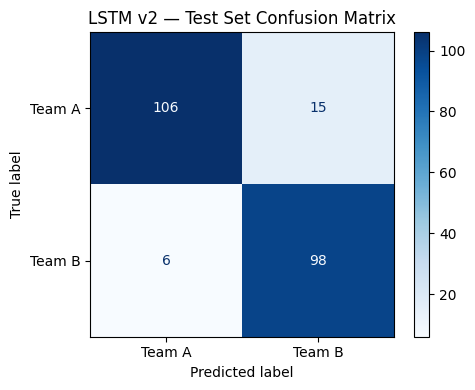

In [21]:
# Confusion matrix for v2
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_v2["confusion_matrix"],
    display_labels=["Team A", "Team B"],
)
disp.plot(ax=ax, cmap="Blues")
ax.set_title("LSTM v2 — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Qualitative Analysis

### 10a. Accuracy vs Rally Length

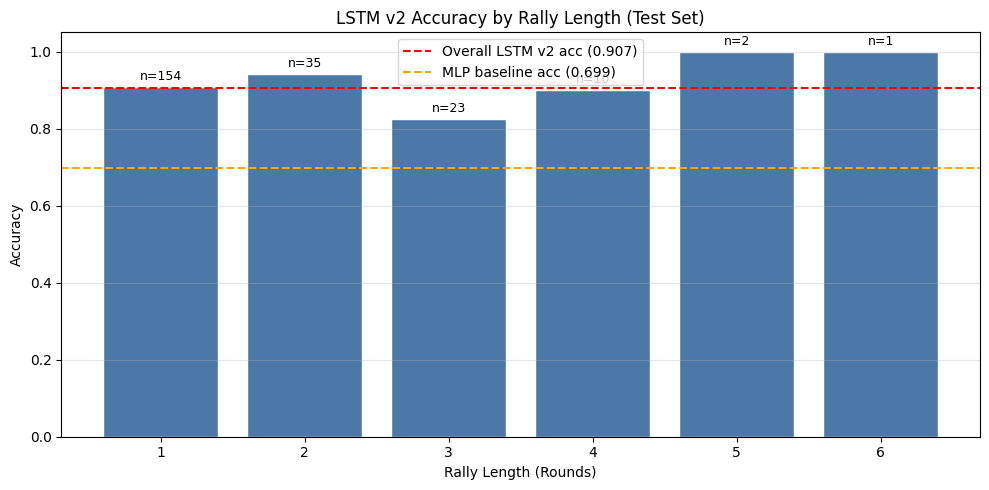

In [22]:
# Collect per-rally predictions with lengths (using v2 model)
test_rally_results = []

model_v2.eval()
with torch.no_grad():
    for cat, cont, labels_batch, lengths, rally_ids in test_loader:
        cat, cont = cat.to(device), cont.to(device)
        logits = model_v2(cat, cont, lengths)
        probs = torch.sigmoid(logits).cpu().numpy()
        labels_np = labels_batch.numpy()
        lengths_np = lengths.numpy()

        for i in range(len(labels_np)):
            test_rally_results.append({
                "rally_id": rally_ids[i],
                "length": lengths_np[i],
                "true_label": int(labels_np[i]),
                "pred_prob": probs[i],
                "pred_label": int(probs[i] >= 0.5),
                "correct": int((probs[i] >= 0.5) == labels_np[i]),
            })

results_df = pd.DataFrame(test_rally_results)

# Accuracy by rally length
acc_by_length = results_df.groupby("length").agg(
    accuracy=("correct", "mean"),
    count=("correct", "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(acc_by_length["length"], acc_by_length["accuracy"],
              color="#4C78A8", edgecolor="white")
ax.axhline(y=test_v2["accuracy"], color="red", linestyle="--",
           label=f"Overall LSTM v2 acc ({test_v2['accuracy']:.3f})")
ax.axhline(y=0.6986, color="orange", linestyle="--",
           label="MLP baseline acc (0.699)")

for bar, count in zip(bars, acc_by_length["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"n={count}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Rally Length (Rounds)")
ax.set_ylabel("Accuracy")
ax.set_title("LSTM v2 Accuracy by Rally Length (Test Set)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 10b. Sample Rally Predictions

In [23]:
# Select interesting rallies from test set
correct_long = results_df[(results_df["correct"] == 1) & (results_df["length"] >= 3)].head(2)
wrong_long = results_df[(results_df["correct"] == 0) & (results_df["length"] >= 3)].head(2)
confident = results_df.iloc[(results_df["pred_prob"] - 0.5).abs().argsort()[-2:][::-1]]
uncertain = results_df.iloc[(results_df["pred_prob"] - 0.5).abs().argsort()[:2]]

sample_rallies = pd.concat([correct_long, wrong_long, confident, uncertain]).drop_duplicates("rally_id")

display_cols = ["round", "team", "serve_type", "set_location", "hit_type",
                "num_blockers", "block_touch", "pass_rating"]

for _, row in sample_rallies.iterrows():
    rally_id = row["rally_id"]
    rally_rows = df[df["unique_rally"] == rally_id][display_cols]
    true_winner = "Team A" if row["true_label"] == 0 else "Team B"
    pred_winner = "Team A" if row["pred_label"] == 0 else "Team B"
    status = "CORRECT" if row["correct"] else "WRONG"

    print(f"{'='*70}")
    print(f"Rally: {rally_id} | Length: {row['length']} rounds")
    print(f"True: {true_winner} | Predicted: {pred_winner} (prob={row['pred_prob']:.3f}) | {status}")
    print(f"{'-'*70}")
    print(rally_rows.to_string(index=False))
    print()

Rally: 0_27 | Length: 3 rounds
True: Team A | Predicted: Team A (prob=0.139) | CORRECT
----------------------------------------------------------------------
 round team serve_type set_location  hit_type  num_blockers block_touch pass_rating
   1.0    b      float      outside       hit           2.0         yes          in
   2.0    a        NaN      outside       hit           2.0          no          in
   3.0    b        NaN       d-ball free_ball           0.0          no         out

Rally: 3_27 | Length: 6 rounds
True: Team A | Predicted: Team A (prob=0.042) | CORRECT
----------------------------------------------------------------------
 round team serve_type set_location  hit_type  num_blockers block_touch pass_rating
   1.0    a       jump         dump      dump           1.0         yes          in
   2.0    b        NaN          NaN free_ball           0.0          no         out
   3.0    a        NaN      outside       tip           1.0         yes         out
   4.0    b

## 11. External validation (`new_data.csv`)

Run **after** training **LSTM v2** (`model_v2` loaded with best validation weights). Loads hand-annotated rallies from `new_data.csv`, encodes them with the **same** `encode_row` / `MAX_ROUND` as the training pipeline, and reports accuracy (and ROC-AUC when both classes are present).

In [26]:
# --- External validation on new_data.csv (LSTM v2) ---
# Requires: trained `model_v2`, `CAT_FEATURES`, `CAT_COL_ORDER`, `LOCATION_COLS`,
# `encode_row`, `MAX_ROUND`, `RallyDataset`, `collate_fn`, `evaluate`, `device`, `criterion_v2`

NEW_PATH = Path("new_data.csv")
assert NEW_PATH.exists(), f"Place {NEW_PATH.resolve()} next to this notebook."


def clean_vren_frame(raw: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace; empty strings -> NaN; coerce location/numeric columns."""
    out = raw.copy()
    for c in out.columns:
        if out[c].dtype == object:
            out[c] = out[c].apply(
                lambda x: np.nan if (isinstance(x, str) and not str(x).strip()) else x
            )
            out[c] = out[c].apply(lambda x: str(x).strip() if isinstance(x, str) else x)
    text_cols = {
        "team", "pass_rating", "set_type", "set_location", "hit_type",
        "block_touch", "serve_type", "win_reason", "lose_reason", "winning_team",
    }
    for c in out.columns:
        if c not in text_cols:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


df_new_raw = pd.read_csv(NEW_PATH)
df_new = clean_vren_frame(df_new_raw)
# Training `df` drops win_reason / lose_reason — compare to the raw file header, not `df.columns`
SCHEMA_PATH = Path("dataset_full.csv")
assert SCHEMA_PATH.exists(), f"Missing {SCHEMA_PATH.resolve()} for column schema."
EXPECTED_COLS = list(pd.read_csv(SCHEMA_PATH, nrows=0).columns)
assert list(df_new.columns) == EXPECTED_COLS, (
    "new_data.csv columns must match dataset_full.csv (18 columns, including win_reason & lose_reason)"
)

# game_id / unique_rally (same logic as §1)
game_ids_new = [0]
for i in range(1, len(df_new)):
    if df_new.iloc[i]["rally"] < df_new.iloc[i - 1]["rally"]:
        game_ids_new.append(game_ids_new[-1] + 1)
    else:
        game_ids_new.append(game_ids_new[-1])
df_new["game_id"] = game_ids_new
df_new["unique_rally"] = df_new["game_id"].astype(str) + "_" + df_new["rally"].astype(str)

assert df_new.groupby("unique_rally")["winning_team"].nunique().max() == 1, (
    "winning_team must be constant within each rally"
)

new_rally_data = []
for rally_id, group in df_new.groupby("unique_rally", sort=False):
    group = group.sort_values("round")
    label = 1 if group["winning_team"].iloc[0] == "b" else 0
    cat_rows, cont_rows = [], []
    for _, row in group.iterrows():
        cat_idx, cont_val = encode_row(row)
        cat_rows.append(cat_idx)
        cont_rows.append([cont_val])
    cat_tensor = torch.tensor(cat_rows, dtype=torch.long)
    cont_tensor = torch.tensor(cont_rows, dtype=torch.float32)
    new_rally_data.append((cat_tensor, cont_tensor, label, len(group), rally_id))

new_indices = np.arange(len(new_rally_data))
new_ds = RallyDataset(new_rally_data, new_indices)
new_loader = DataLoader(
    new_ds,
    batch_size=max(1, len(new_ds)),
    shuffle=False,
    collate_fn=collate_fn,
)

metrics_new = evaluate(model_v2, new_loader, criterion_v2)

print("New data (new_data.csv) — LSTM v2")
print(f"  Rallies: {len(new_rally_data)}")
print(f"  Accuracy: {metrics_new['accuracy']:.4f}")
if len(np.unique(metrics_new["targets"])) > 1:
    print(f"  ROC-AUC:  {metrics_new['auc']:.4f}")
else:
    print("  ROC-AUC:  n/a (only one class in labels)")
print(f"  Loss:     {metrics_new['loss']:.4f}")

New data (new_data.csv) — LSTM v2
  Rallies: 30
  Accuracy: 0.8000
  ROC-AUC:  0.8914
  Loss:     0.4975
